In [1]:
import pandas as pd
import seaborn as sns
from sklearn.naive_bayes import MultinomialNB
from sklearn.model_selection import train_test_split
from sklearn.feature_extraction.text import CountVectorizer
from sklearn.preprocessing import LabelEncoder
import joblib

In [2]:
data = pd.read_csv(r"C:\Users\USER\Downloads\spam_mail_classifier.csv")

In [3]:
data

,email_text,label
0,Let's catch up sometime next week!,ham
1,Don't forget to submit your project by Friday.,ham
2,Win a free iPhone now!!! Click here.,spam
3,Can you send me the report when it's ready?,ham
4,Meeting has been rescheduled to next Monday.,ham
...,...,...
995,Don't forget to submit your project by Friday.,ham
996,Meeting has been rescheduled to next Monday.,ham
997,Let's catch up sometime next week!,ham
998,Win a free iPhone now!!! Click here.,spam


In [4]:
data.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 1000 entries, 0 to 999
Data columns (total 2 columns):
 #   Column      Non-Null Count  Dtype 
---  ------      --------------  ----- 
 0   email_text  1000 non-null   object
 1   label       1000 non-null   object
dtypes: object(2)
memory usage: 15.8+ KB


In [5]:
data.shape

(1000, 2)

In [6]:
data.describe()

,email_text,label
count,1000,1000
unique,10,2
top,Let's catch up sometime next week!,ham
freq,129,583


<Axes: xlabel='label', ylabel='count'>

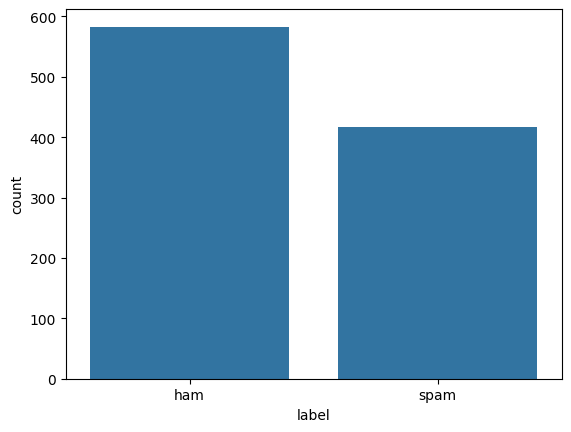

In [7]:
sns.countplot(data =data , x = 'label')

In [8]:
encoder = LabelEncoder()

data['label'] = encoder.fit_transform(data['label']) # 0 not spam , 1 spam

In [9]:
data.head()

,email_text,label
0,Let's catch up sometime next week!,0
1,Don't forget to submit your project by Friday.,0
2,Win a free iPhone now!!! Click here.,1
3,Can you send me the report when it's ready?,0
4,Meeting has been rescheduled to next Monday.,0


In [10]:
X = data['email_text']
Y = data['label']

v = CountVectorizer()

X_train , X_test, Y_train , Y_test = train_test_split(X, Y, test_size = 0.2 , stratify = Y,random_state = 43)

X_train_count = v.fit_transform(X_train)
X_test_count = v.transform(X_test)

from sklearn.metrics import accuracy_score, confusion_matrix
model = MultinomialNB()

model.fit(X_train_count, Y_train)

y_pred = model.predict(X_test_count)
print(accuracy_score(Y_test, y_pred))
print(confusion_matrix(Y_test, y_pred))

1.0
[[117   0]
 [  0  83]]
